# Section 2 - Syntax Summary, Part 2

## Working with a real data file

In Part 1 we built every table inline (in the notebook) so you could edit the numbers. However, real data does not
arrive that way. Sometimes, it arrives as a file that has more columns than you want, it may have column
names nobody would normally choose, and rows that are not what they appear to be.

Getting a file of data into a usable state is most of the work in a real data analysis. We normally apply following steps:

1. **Load** the data and look at it
2. **Select** the columns you actually need
3. **Relabel** anything you find unreadable
4. **Filter out** rows that are not real data observations

This notebook needs the file `nc-est2019-agesex-res.csv` to be in the same folder.

The `.csv` is the US Census Bureau's population estimates by age and sex. It is a real data 
file, downloaded as published.


In [1]:
# Run this cell first - the install takes about a minute
%pip install -q urllib3<2.0 otter-grader datascience ipywidgets

try:
    import pyodide_http
    pyodide_http.patch_all()
except ImportError:
    pass

from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

The system cannot find the file specified.


Note: you may need to restart the kernel to use updated packages.


---

## 1. Load it, and look at it

`Table.read_table(filename)` reads a CSV and returns a table. The file must be in
the same folder as this notebook, or you get a `FileNotFoundError`.

**Always look at what you loaded before doing anything with it.**


In [ ]:
full = Table.read_table('nc-est2019-agesex-res.csv')
full.show(5)

SEX,AGE,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015,POPESTIMATE2016,POPESTIMATE2017,POPESTIMATE2018,POPESTIMATE2019
0,0,3944153,3944160,3951430,3963092,3926570,3931258,3954787,3983981,3954773,3893990,3815343,3783052
0,1,3978070,3978090,3957730,3966225,3977549,3942698,3948891,3973133,4002903,3972711,3908830,3829599
0,2,4096929,4096939,4090621,3970654,3978925,3991740,3958711,3966321,3991349,4020045,3987032,3922044
0,3,4119040,4119051,4111688,4101644,3981531,3991017,4005928,3974351,3982984,4006946,4033038,3998665
0,4,4063170,4063186,4077346,4121488,4111490,3992502,4004032,4020292,3989750,3997280,4018719,4043323


**Check how big the `Table` is, and what are the names of the columns?**

In [ ]:

print(full.num_rows, 'rows')
print(full.num_columns, 'columns')
full.labels

306 rows
14 columns


('SEX',
 'AGE',
 'CENSUS2010POP',
 'ESTIMATESBASE2010',
 'POPESTIMATE2010',
 'POPESTIMATE2011',
 'POPESTIMATE2012',
 'POPESTIMATE2013',
 'POPESTIMATE2014',
 'POPESTIMATE2015',
 'POPESTIMATE2016',
 'POPESTIMATE2017',
 'POPESTIMATE2018',
 'POPESTIMATE2019')

The table contains population estimates by age and sex, one column per year from 2010 to 2019.
Three things are already unusual about the data:

- **14 columns**, but we only want to look at three of them
- `POPESTIMATE2019` is how a statistical agency names things, it may not be a name that is easy to read on an axis label
- `CENSUS2010POP` and `ESTIMATESBASE2010` are two different kinds of data from 2010. you would have to read the documentation to know what they mean

Real files look like this.


---

## 2. Select the columns you need

`.select(...)` keeps only the columns you name, in the order you name them. It
returns a **new** table.

Take note, the original remains untouched.

Selecting the columns you need early makes reading the table easier later on.

We will select 3 columns 'SEX', 'AGE', 'POPESTIMATE2019'


In [ ]:
partial = full.select('SEX', 'AGE', 'POPESTIMATE2019')
partial.show(5)

SEX,AGE,POPESTIMATE2019
0,0,3783052
0,1,3829599
0,2,3922044
0,3,3998665
0,4,4043323


The original table still has all 14 columns.
Using `.select()` did not change it. We can confirm using `.labels`

In [ ]:
full.labels

('SEX',
 'AGE',
 'CENSUS2010POP',
 'ESTIMATESBASE2010',
 'POPESTIMATE2010',
 'POPESTIMATE2011',
 'POPESTIMATE2012',
 'POPESTIMATE2013',
 'POPESTIMATE2014',
 'POPESTIMATE2015',
 'POPESTIMATE2016',
 'POPESTIMATE2017',
 'POPESTIMATE2018',
 'POPESTIMATE2019')

> `.drop(...)` is the mirror image of `.select()`: 
> We name the columns we want to **remove** rather than columns we want to keep. 
> Use whichever needs less typing: i.e. `.select` when you want a few columns out of many,
> `.drop` when you want to keep most of the columns and get rid of a few.


---

## 3. Relabel for readability

`.relabeled(old, new)` renames a column. `old` can be the current label or the
column's position, counting from 0.

This is cosmetic, and it matters. You will type these names dozens of times, and
they end up as axis labels on every plot you draw.

By position: column 2 in our table is POPESTIMATE2019

We can relabel it to 2019

In [ ]:
us_pop = partial.relabeled(2, '2019')
us_pop.show(5)

SEX,AGE,2019
0,0,3783052
0,1,3829599
0,2,3922044
0,3,3998665
0,4,4043323


We can relabel it by. Use whichever is clearer

In [ ]:
partial.relabeled('POPESTIMATE2019', '2019').show(3)

SEX,AGE,2019
0,0,3783052
0,1,3829599
0,2,3922044


---

## 4. Filter out rows that are not observations

This is the step people miss, and it is the one that silently ruins results.

Look at the values in each column before assuming you know what they mean.

For example: What values does SEX in our dataset actually take?


In [ ]:
us_pop.group('SEX')

SEX,count
0,102
1,102
2,102


It has 3 values, 0, 1 and 2

Next, look at the data in the column AGE. Look at the largest values

In [ ]:
us_pop.sort('AGE', descending=True).show(6)

SEX,AGE,2019
0,999,328239523
1,999,161657324
2,999,166582199
0,100,100322
1,100,23472
2,100,76850


Two traps, both common in official statistics:

**`AGE` of 999 is not an age.** It is the row holding the total across all ages.

**`SEX` of 0 is not a sex.** It is the total across both.

Neither is flagged. None produces errors. If you leave them in and add up the
population column, you count everybody roughly **four times**:
- once as an individual row, 
- once in the age total, 
- once in the sex total, and 
- once in the row that is both.

A value used as a marker rather than a measurement is called a **sentinel
value**. 

Look for them in any file you did not create yourself.

To see how what this error costs, in numbers we do some calculations:


In [ ]:
everything = sum(us_pop.column('2019'))
print('Adding up every row:      ', f'{everything:,}')

real_rows = us_pop.where('AGE', are.below(999)).where('SEX', are.above(0))
print('Adding up only real rows: ', f'{sum(real_rows.column("2019")):,}')
print()
print('Overcounted by a factor of', round(everything / sum(real_rows.column('2019')), 1))

Adding up every row:       1,312,958,092
Adding up only real rows:  328,239,523

Overcounted by a factor of 4.0


### Keeping the total row on purpose

Sometimes the sentinel is exactly what you want. To get one row per age with
**both sexes combined**, keep `SEX` 0 and drop `AGE` 999.


In [ ]:
by_age = us_pop.where('AGE', are.below(999)).where('SEX', 0)
by_age.show(5)

SEX,AGE,2019
0,0,3783052
0,1,3829599
0,2,3922044
0,3,3998665
0,4,4043323


In [ ]:
print(by_age.num_rows, 'rows -- one per age from 0 to 100')
print('Total population:', f"{sum(by_age.column('2019')):,}")

101 rows -- one per age from 0 to 100
Total population: 328,239,523


---

## 5. Rescale so the numbers can be read

58 million is hard to read on an axis (it has too many zeros), 
It is also impossible to compare by eye. 

To make it easier to read Divide the population column by a million, and create a column named `Millions`.

Take note: `1e6` below is Python's shorthand for 1000000 (scientific notation).


In [ ]:
by_age = by_age.with_column('Millions', by_age.column('2019') / 1e6)
by_age.show(5)

SEX,AGE,2019,Millions
0,0,3783052,3.78305
0,1,3829599,3.8296
0,2,3922044,3.92204
0,3,3998665,3.99866
0,4,4043323,4.04332


### Now the plot is worth drawing

`AGE` is ordered, so we use a line plot.


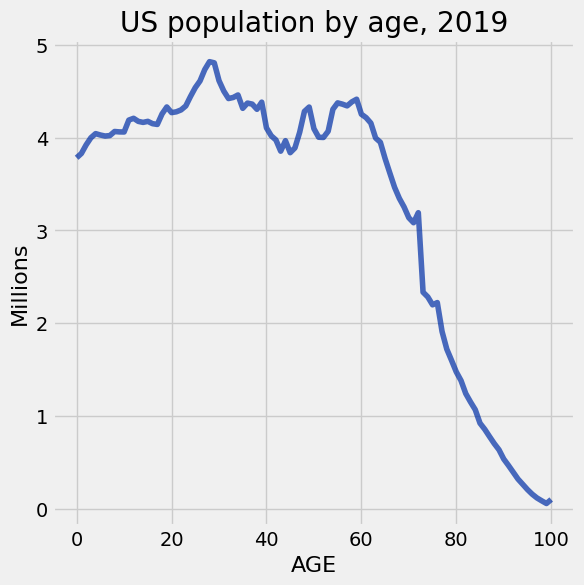

In [ ]:
by_age.plot('AGE', 'Millions')
plots.title('US population by age, 2019')
plots.show()

The shape carries real information, and it is not smooth. There is a dip around
ages 55 to 60 with bulges either side - the trough between the post-war baby boom
and the generation after it. Births in the late 1960s and early 1970s fell, and
that cohort is still visible in the data fifty years later.

There is also a spike at the far right. Age 100 is the last row in the file, so
everyone aged 100 **or older** is counted there - roughly 100,000 people, against
57,000 aged 99. That is another sentinel, hiding in plain sight as a plausible
age.

Whether you can see any of this depends on having removed the 999 rows first.
Try re-running the plot without the filter. Can you see one enormous spike at 999. It makes the actual data appear flat.

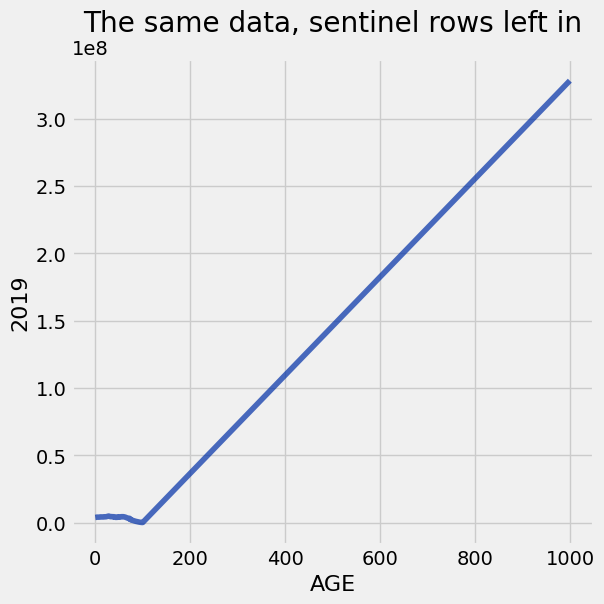

In [ ]:
us_pop.where('SEX', 0).plot('AGE', '2019')
plots.title('The same data, sentinel rows left in')
plots.show()

---

## 6. Comparing two groups from the same file

The whole point of keeping `SEX` was to be able to split by it.


In [ ]:
males   = us_pop.where('AGE', are.below(999)).where('SEX', 1)
females = us_pop.where('AGE', are.below(999)).where('SEX', 2)

sexes = Table().with_columns(
    'Age',     males.column('AGE'),
    'Male',    males.column('2019') / 1e6,
    'Female',  females.column('2019') / 1e6)
sexes.show(5)

Age,Male,Female
0,1.93512,1.84794
1,1.95859,1.87101
2,2.00554,1.9165
3,2.04301,1.95565
4,2.06695,1.97637


Using `.plot()` with only an x column plots every remaining column as its own line

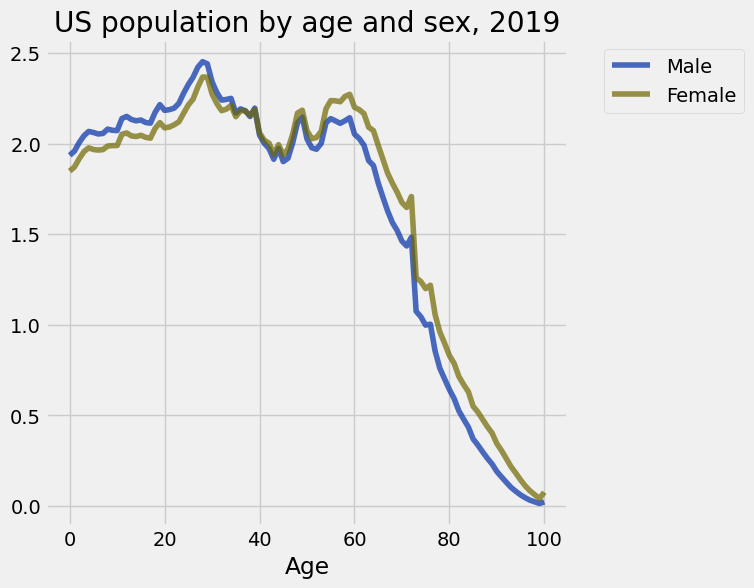

In [ ]:
sexes.plot('Age')
plots.title('US population by age and sex, 2019')
plots.show()

It may be easier to read the ratio of Females per male than to read than two nearly-identical lines

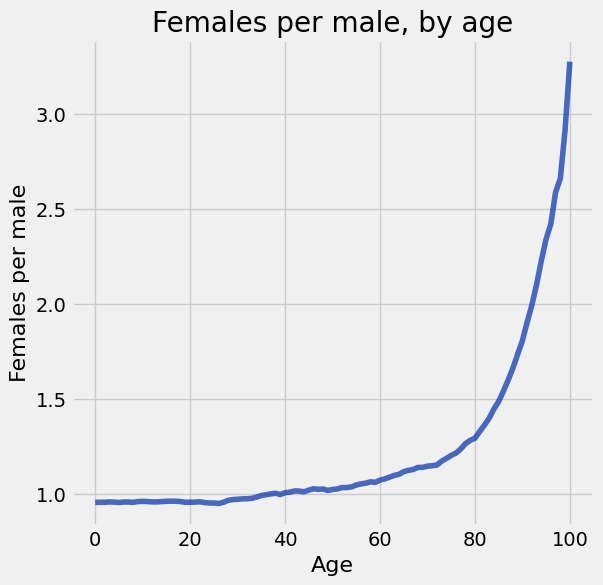

In [ ]:
sexes = sexes.with_column('Females per male', sexes.column('Female') / sexes.column('Male'))
sexes.plot('Age', 'Females per male')
plots.title('Females per male, by age')
plots.show()

Slightly more boys are born than girls. At the start, the ratio starts near 0.95. 
The lines cross at about **age 38**. After that women outnumber men, and by age 100
there are more than three women for every man.

None of that was visible in the two overlapping lines above. The right *derived*
quantity often shows what the raw one hides - a point that returns in Section 6,
when residuals reveal what a scatter plot does not.


---

## 7. The recipe, and what to watch for

Every time you open a file you have not used before:

```python
tbl = Table.read_table('file.csv')         # 1. load the data
tbl.show(5)                                #    LOOK at it
tbl.labels                                 #    what are the columns called?
tbl.num_rows                               #    how big is the data?

tbl.group('some_column')                   # 2. what values does each column take?

small = tbl.select('a', 'b', 'c')          # 3. keep what you need
small = small.relabeled('UGLY', 'x')       # 4. rename what is unreadable
clean = small.where('x', are.below(999))   # 5. drop the non-observations
```

### Checklist

| Check | Why |
|---|---|
| `.show(5)` before anything else | You cannot filter what you have not seen |
| `.labels` | Column names are rarely what you assumed |
| `.group(col)` on each categorical column | Reveals sentinel codes like 0 or 999 |
| `.sort(col, descending=True).show(5)` on numeric columns | Reveals 999, 9999, −1 at the extremes |
| `num_rows` before and after filtering | Confirms you removed what you meant to |
| Does the total look plausible? | 1.3 billion Americans means you left the total rows in |

### Sentinels you will meet

| Value | Usually means |
|---|---|
| 999, 9999 | "all", "total", or "unknown" |
| 0 in a category column | "all categories combined" |
| −1 | "missing" or "not applicable" |
| Blank or `nan` | Genuinely missing |

None of these announce themselves. The only defence is looking at the data
before you compute on it.

---

### Methods in this notebook

| Call | Does |
|---|---|
| `Table.read_table(file)` | Reads a CSV into a table |
| `tbl.labels` | The column names, as a tuple |
| `tbl.select(...)` | Keeps only the named columns |
| `tbl.drop(...)` | Removes the named columns |
| `tbl.relabeled(old, new)` | Renames a column, by name or position |
| `tbl.where(col, are.below(n))` | Keeps rows where the condition holds |
| `tbl.with_column(name, values)` | Adds a column |
| `tbl.plot(x)` | Plots every other column against x |
